In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [4]:
print("=" *60)
print("Email Spam Detection Model")
print("=" *60)

Email Spam Detection Model


In [6]:
df = pd.read_csv("G:\\Machine Learning Projects\\Project_08_SPAM_Email_Detector\\data\\spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

In [9]:
df.shape

(5572, 2)

## Exploratory Data analysis

In [10]:
print("Class Distribution:")
print(df['label'].value_counts())


Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [11]:
spam_count = df[df['label'] == 'spam'].shape[0]
ham_count = df[df['label'] == 'ham'].shape[0]
total = len(df)
spam_percentage = (spam_count / total) * 100

print(f"Spam messages: {spam_count} ({spam_percentage:.2f}%)")
print(f"Ham messages: {ham_count} ({100-spam_percentage:.2f}%)")

print(f"This is an imbalanced dataset! Only {spam_percentage:.1f}% is spam.")


Spam messages: 747 (13.41%)
Ham messages: 4825 (86.59%)
This is an imbalanced dataset! Only 13.4% is spam.


## FEATURE ENGINEERING

In [16]:
df['text_length'] = df['text'].str.len()

df['word_count'] = df['text'].str.split().str.len()
df['has_url'] = df['text'].str.contains('www|http|https|.com|.net',case=False).astype(int)
df['has_phone'] = df['text'].str.contains(r'\d{3}-\d{3}-\d{4}|\(?\d{3}\)?[-.\s]?\d{3}[-,\s]?\d{4}|\d{4}', case=False).astype(int)

In [17]:
print("\n New features created:")
print(f"  - text_length: length of message")
print(f"  - word_count: number of words in message")
print(f"  - has_url: whether message contains a URL")
print(f"  - has_phone: whether message contains a phone number")


 New features created:
  - text_length: length of message
  - word_count: number of words in message
  - has_url: whether message contains a URL
  - has_phone: whether message contains a phone number


## VISUALIZE

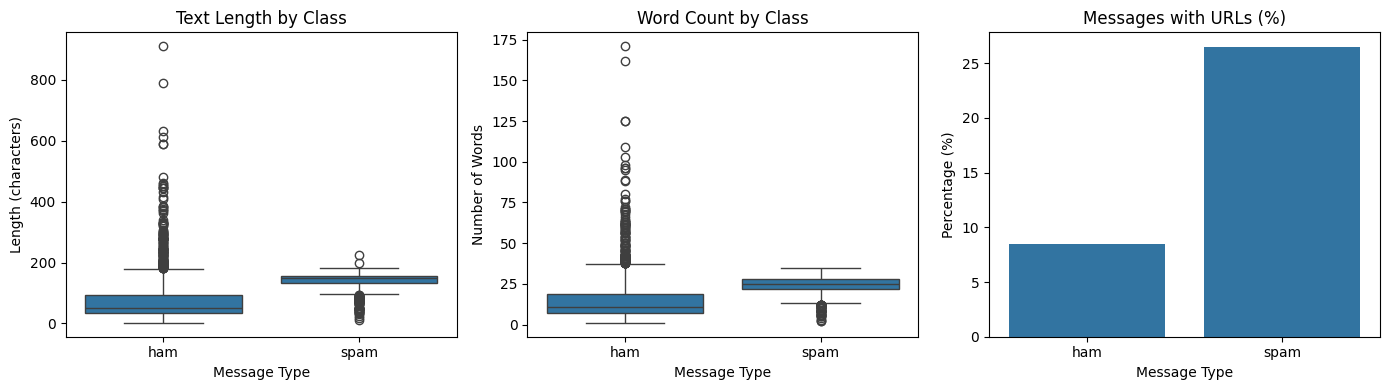

In [18]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='label', y='text_length')
plt.title("Text Length by Class")
plt.xlabel('Message Type')
plt.ylabel('Length (characters)')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='label', y='word_count')
plt.title("Word Count by Class")
plt.xlabel('Message Type')
plt.ylabel('Number of Words')

plt.subplot(1, 3, 3)
url_counts = df.groupby('label')['has_url'].mean() * 100
sns.barplot(x=url_counts.index, y=url_counts.values)
plt.title("Messages with URLs (%)")
plt.xlabel('Message Type')
plt.ylabel('Percentage (%)')

plt.tight_layout()
plt.savefig("G:\\Machine Learning Projects\\Project_08_SPAM_Email_Detector\\feature_analysis.png")
plt.show()

In [19]:
print("Average Statistics")
print(df.groupby('label')[['text_length', 'word_count']].mean().round(2))

Average Statistics
       text_length  word_count
label                         
ham          71.02       14.20
spam        138.87       23.85


In [20]:
print("Top words in SPAM messages:")
spam_text = ' '.join(df[df['label']=='spam']['text'])
from collections import Counter
spam_words = Counter(spam_text.lower().split()).most_common(10)
for word, count in spam_words:
    print(f"{word}: {count}")

print("\nTop words in HAM messages:")
ham_text = ' '.join(df[df['label']=='ham']['text'])
ham_words = Counter(ham_text.lower().split()).most_common(10)
for word, count in ham_words:
    print(f"{word}: {count}")

Top words in SPAM messages:
to: 682
a: 373
call: 342
your: 263
you: 252
the: 204
for: 201
or: 188
free: 180
2: 169

Top words in HAM messages:
i: 2172
you: 1665
to: 1544
the: 1113
a: 1046
u: 874
and: 845
in: 786
my: 741
is: 710


## TEXT CLEANING

In [21]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('','', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())

    return text

In [22]:
sample_message = df['text'].iloc[0]
cleaned_sample = clean_text(sample_message)

print(f"Original: {sample_message}")
print(f"Cleaned: {cleaned_sample}")

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [25]:
print(" Cleaning all messages...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning complete!")

 Cleaning all messages...
Text cleaning complete!


## LABEL ENCODING

In [23]:
df['label_binary'] = df['label'].map({'ham': 0, 'spam': 1})

print(f" Label mapping:")
print(f"  'ham' → 0 (Not spam)")
print(f"  'spam' → 1 (Spam)")
print(f"\nValue counts:")
print(df['label_binary'].value_counts())


 Label mapping:
  'ham' → 0 (Not spam)
  'spam' → 1 (Spam)

Value counts:
label_binary
0    4825
1     747
Name: count, dtype: int64


In [26]:
x = df['cleaned_text']
y = df['label_binary']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Training spam rate: {y_train.mean()*100:.2f}%")
print(f"Test spam rate: {y_test.mean()*100:.2f}%")

Training samples: 4,457
Test samples: 1,115
Training spam rate: 13.42%
Test spam rate: 13.36%


## FEATURE EXTRACTION (TF-IDF)

In [27]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
print("Transforming training data...")
X_train_tfidf = vectorizer.fit_transform(X_train)
print(" Training data transformation complete!")

print("Transforming test data...")
X_test_tfidf = vectorizer.transform(X_test)
print(" Test data transformation complete!")


Transforming training data...
 Training data transformation complete!
Transforming test data...
 Test data transformation complete!


In [29]:
print(f"TF-IDF features created!")
print(f"   Number of features: {X_train_tfidf.shape[1]:,}")
print(f"   Training matrix shape: {X_train_tfidf.shape}")
print(f"   Test matrix shape: {X_test_tfidf.shape}")
print(f"   Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

TF-IDF features created!
   Number of features: 5,000
   Training matrix shape: (4457, 5000)
   Test matrix shape: (1115, 5000)
   Sparsity: 99.84%


In [30]:
feature_names = vectorizer.get_feature_names_out()
print(f"\n Example features (first 20): {feature_names[:20].tolist()}")


 Example features (first 20): ['aathilove', 'aathilove lot', 'abi', 'abiola', 'able', 'abt', 'ac', 'acc', 'accept', 'access', 'accidentally', 'account', 'account statement', 'ache', 'action', 'activate', 'activities', 'actually', 'ad', 'add']


## TRANING MODELS

In [33]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM' : SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("Training each model...")

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    try:
        y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    except:
        y_proba = None

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
    }

    if y_proba is not None:
        results[name]['ROC-AUC'] = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {results[name]['Accuracy']:.4f}")
    print(f"Precision: {results[name]['Precision']:.4f}")
    print(f"Recall: {results[name]['Recall']:.4f}")
    print(f"F1 Score: {results[name]['F1 Score']:.4f}")
    print()

Training each model...

Training Naive Bayes...
Accuracy: 0.9650
Precision: 0.9911
Recall: 0.7450
F1 Score: 0.8506


Training Logistic Regression...
Accuracy: 0.9659
Precision: 0.9912
Recall: 0.7517
F1 Score: 0.8550


Training SVM...
Accuracy: 0.9857
Precision: 0.9926
Recall: 0.8993
F1 Score: 0.9437


Training Random Forest...
Accuracy: 0.9758
Precision: 0.9919
Recall: 0.8255
F1 Score: 0.9011



## MODEL COMPARISON

In [34]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4) * 100
print("Performance Comparison:")

best_model_name = comparison_df['F1 Score'].idxmax()
print(f"Best model: {best_model_name}")
print(f"F1-Score: {comparison_df.loc[best_model_name, 'F1 Score']:.2f}%")

best_model = models[best_model_name]

Performance Comparison:
Best model: SVM
F1-Score: 94.37%


## CONFUSION MATRIX

In [35]:
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print("                Predicted")
print("                Ham    Spam")
print(f"Actual Ham     {cm[0, 0]:<6} {cm[0, 1]:<6}")
print(f"Actual Spam    {cm[1, 0]:<6} {cm[1, 1]:<6}")


Confusion Matrix:
                Predicted
                Ham    Spam
Actual Ham     965    1     
Actual Spam    15     134   


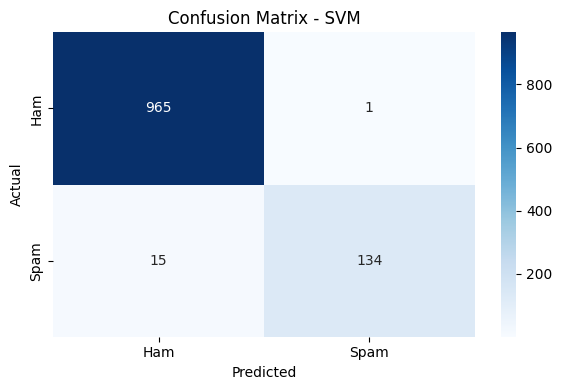

In [36]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("G:\\Machine Learning Projects\\Project_08_SPAM_Email_Detector\\confusion_matrix.png")


## SAVING MODELS

In [ ]:

# Save the best model
joblib.dump(best_model, 'models/spam_model.pkl')
print(" Model saved to 'models/spam_model.pkl'")

# Save the vectorizer
joblib.dump(vectorizer, 'models/vectorizer.pkl')
print(" Vectorizer saved to 'models/vectorizer.pkl'")

# Save metadata
metadata = {
    'model_name': best_model_name,
    'n_features': X_train_tfidf.shape[1],
    'spam_rate': y.mean(),
    'n_samples': len(df),
    'performance': comparison_df.loc[best_model_name].to_dict()
}
joblib.dump(metadata, 'models/metadata.pkl')
print("Metadata saved to 'models/metadata.pkl'")


## TRAINING COMPLETED

In [41]:

print("\nFinal Summary:")
print(f"  Dataset: SMS Spam Collection")
print(f"  Total messages: {len(df):,}")
print(f"  Spam rate: {y.mean()*100:.2f}%")
print(f"  Best model: {best_model_name}")
print(f"  TF-IDF features: {X_train_tfidf.shape[1]:,}")

print("\n Performance on Test Set:")
print(f"  Accuracy:  {comparison_df.loc[best_model_name, 'Accuracy']:.1f}%")
print(f"  Precision: {comparison_df.loc[best_model_name, 'Precision']:.1f}%")
print(f"  Recall:    {comparison_df.loc[best_model_name, 'Recall']:.1f}%")




Final Summary:
  Dataset: SMS Spam Collection
  Total messages: 5,572
  Spam rate: 13.41%
  Best model: SVM
  TF-IDF features: 5,000

 Performance on Test Set:
  Accuracy:  98.6%
  Precision: 99.3%
  Recall:    89.9%
